## Data Analytics

### Chapter 17: Outliers Detection

Detecting outliers is an important preprocessing task because they may significantly influence statistical analysis and machine learning models.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
n = 200
outlier_ratio = 0.20
n_outliers = int(n * outlier_ratio)
n_normal = n - n_outliers

# Normal samples
height_normal = np.random.normal(170, 8, n_normal)
weight_normal = 0.45 * height_normal - 5 + np.random.normal(0, 4, n_normal)

# Outliers
height_outlier = np.random.uniform(120, 220, n_outliers)
weight_outlier = np.random.uniform(25, 130, n_outliers)

height = np.concatenate([height_normal, height_outlier])
weight = np.concatenate([weight_normal, weight_outlier])

df = pd.DataFrame({
    "Height": np.round(height, 1),
    "Weight": np.round(weight, 1)
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head(10)

,Height,Weight
0,158.3,64.3
1,165.5,72.8
2,165.2,67.5
3,160.5,68.5
4,170.8,73.0
5,172.4,74.4
6,164.8,71.9
7,129.1,103.3
8,164.2,55.0
9,164.2,65.2


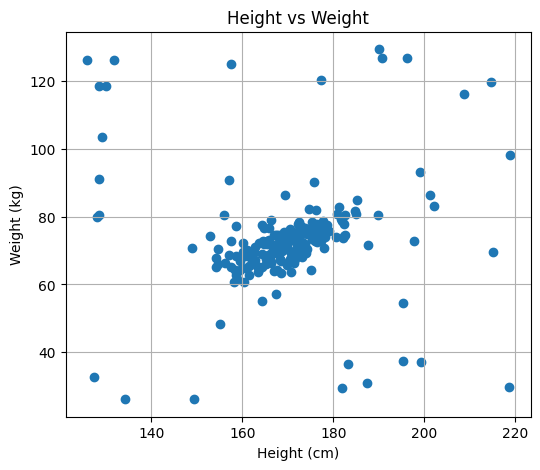

In [4]:
# A scatter plot quickly reveals observations 
# that appear far away from the majority of the data.
plt.figure(figsize=(6,5))
plt.scatter(df["Height"], df["Weight"])
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight")
plt.grid(True)

plt.show()

#### 17.1. Detecting Outliers with Z-Score

The Z-Score measures how many standard deviations a value is from the mean.

In [ ]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df))
# We use max to take the worst outliers, either the height or weight
df['z_scores'] = z_scores.max(axis=1)

outliers = (z_scores > 3).any(axis=1)
df_zscore = df[outliers]

print("Number of outliers:", len(df_zscore))
df_zscore

Number of outliers: 9


,Height,Weight,z_scores
14,190.6,126.8,3.306287
15,131.7,126.1,3.262979
58,125.8,126.0,3.256792
67,218.7,98.1,3.245962
95,218.6,29.8,3.239327
163,190.1,129.3,3.460957
168,157.6,124.8,3.182551
174,215.1,69.5,3.007098
198,196.2,126.8,3.306287


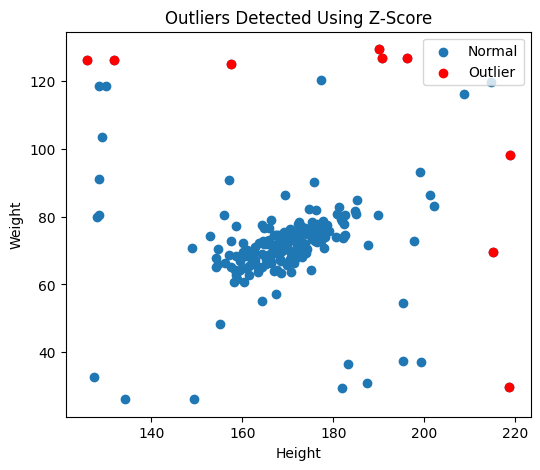

In [10]:
# Visualizing Detected Outliers
plt.figure(figsize=(6,5))

plt.scatter(df["Height"], df["Weight"], label="Normal")
plt.scatter(df_zscore["Height"],
            df_zscore["Weight"],
            color="red",
            label="Outlier")

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Outliers Detected Using Z-Score")
plt.legend()

plt.show()

#### 17.2. Detecting Outliers with Interquartile Range (IQR)

The Interquartile Range (IQR) measures the spread of the middle 50% of the data.

In [11]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df < lower) | (df > upper)).any(axis=1)
df_iqr = df[outliers]

print("Number of outliers:", len(df_iqr))

df_iqr

Number of outliers: 33


,Height,Weight,z_scores
7,129.1,103.3,2.699096
11,128.4,80.4,2.745542
14,190.6,126.8,3.306287
15,131.7,126.1,3.262979
38,149.3,26.2,2.917632
41,128.4,118.5,2.792782
45,195.3,54.5,1.693346
58,125.8,126.0,3.256792
60,199.0,93.2,1.938845
67,218.7,98.1,3.245962


/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_30852/3050731990.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["Height"], df["Weight"]],


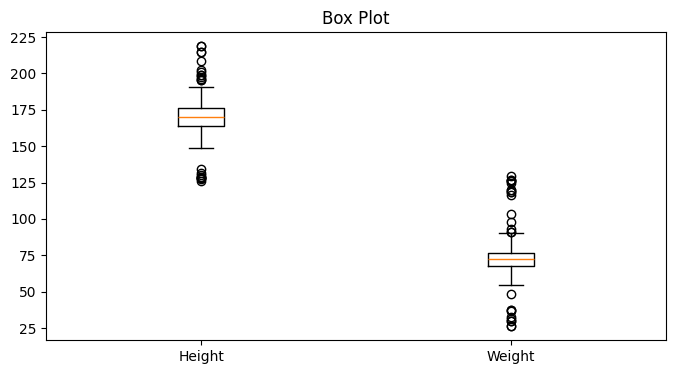

In [12]:
# Visualizing with a Box Plot
plt.figure(figsize=(8,4))

plt.boxplot([df["Height"], df["Weight"]],
            labels=["Height", "Weight"])

plt.title("Box Plot")

plt.show()